<a href="https://colab.research.google.com/github/cyriact/cyriact.github.io/blob/main/Effectiveness_of_Candlesticks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://launchpad.net/~mario-mariomedina/+archive/ubuntu/talib/+files/libta-lib0_0.4.0-oneiric1_amd64.deb -qO libta.deb
!wget https://launchpad.net/~mario-mariomedina/+archive/ubuntu/talib/+files/ta-lib0-dev_0.4.0-oneiric1_amd64.deb -qO ta.deb
!dpkg -i libta.deb ta.deb
!pip install ta-lib
import talib

Selecting previously unselected package libta-lib0.
(Reading database ... 160706 files and directories currently installed.)
Preparing to unpack libta.deb ...
Unpacking libta-lib0 (0.4.0-oneiric1) ...
Selecting previously unselected package ta-lib0-dev.
Preparing to unpack ta.deb ...
Unpacking ta-lib0-dev (0.4.0-oneiric1) ...
Setting up libta-lib0 (0.4.0-oneiric1) ...
Setting up ta-lib0-dev (0.4.0-oneiric1) ...
Processing triggers for man-db (2.8.3-2ubuntu0.1) ...
Processing triggers for libc-bin (2.27-3ubuntu1.2) ...
/sbin/ldconfig.real: /usr/local/lib/python3.7/dist-packages/ideep4py/lib/libmkldnn.so.0 is not a symbolic link

     |████████████████████████████████| 276kB 2.9MB/s 
  Created wheel for ta-lib: filename=TA_Lib-0.4.20-cp37-cp37m-linux_x86_64.whl size=1436187 sha256=e3ae958f6f29033a57e4ab60fd463d504b9410fbd4546236258d78057afd52cd
  Stored in directory: /root/.cache/pip/wheels/d9/2f/34/7636a227222011ad010012e6bdf3a2abfaf1da255d9bdd532b
Successfully built ta-lib


In [ ]:
!pip install yfinance


     |████████████████████████████████| 6.3MB 3.2MB/s 
  Created wheel for yfinance: filename=yfinance-0.1.59-py2.py3-none-any.whl size=23442 sha256=011ebf5f3d94c7dedd537910d68e8fbd4b8df3ab7950de3a0794f1df24a11414
  Stored in directory: /root/.cache/pip/wheels/f8/2a/0f/4b5a86e1d52e451757eb6bc17fd899629f0925c777741b6d04
Successfully built yfinance
  Found existing installation: lxml 4.2.6
    Uninstalling lxml-4.2.6:
      Successfully uninstalled lxml-4.2.6


In [ ]:
import yfinance as yf
import pandas as pd


In [ ]:
data=yf.download("MPHASIS.NS",start="2018-01-01",end="2020-01-01")




num1 = talib.CDL3BLACKCROWS(data['Open'], data['High'], data['Low'], data['Close'])
num2 = talib.CDLDARKCLOUDCOVER(data['Open'], data['High'], data['Low'], data['Close'])
num3 = talib.CDLHARAMI(data['Open'], data['High'], data['Low'], data['Close'])
num4 = talib.CDL3WHITESOLDIERS(data['Open'], data['High'], data['Low'], data['Close'])



data['3blackcrows']=num1
data['darkcouldcover']=num2
data['harami']=num3
data['white soldiers']=num4

t1=pd.Series.count(num1[num1!=0])
t2=pd.Series.count(num2[num2!=0])
t3=pd.Series.count(num3[num3>0])
t4=pd.Series.count(num4[num4!=0])

print("3 Blackcrows: ",t1)
print("Dark Could Cover: ",t2)
print("Bullish Harami ",t3)
print("3 White Soldiers: ",t4)

#print("3Black crows:")
#print(num1[num1!=0])
#print("Dark Could Cover:")
#print(num2[num2!=0])
#print("Bullish Harami:")
#print(num3[num3>0])
#print("3 White soldiers")
#print(num4[num4!=0])

close=data['Close']
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=10)

data['MACD']=macd
data['Signal']=macdsignal
pd.set_option('max_rows', 99999)

real1 = talib.RSI(close, timeperiod=10)
data['RSI']=real1

real2 = talib.SMA(close, timeperiod=10)
data['SMA']=real2

count_macd=0
count_rsi=0
count_sma=0
print(' MACD supports Bullish Harami')
df=pd.DataFrame(data,columns=['MACD','Signal','harami'])
rslt_df1 = df[df['harami'] > 0]
for i in range(1,len(rslt_df1)):
 if rslt_df1['MACD'][i] > rslt_df1['Signal'][i] and rslt_df1['MACD'][i-1] < rslt_df1['Signal'][i-1]:
    count_macd=count_macd+1
 elif rslt_df1['MACD'][i] < rslt_df1['Signal'][i] and rslt_df1['MACD'][i-1] > rslt_df1['Signal'][i-1]:
    count_macd= count_macd+1
print(count_macd/t3)

print('Supporting RSI')
df=pd.DataFrame(data,columns=['RSI','harami'])
rslt_df1 = df[df['harami'] > 0]
for i in range(1,len(rslt_df1)):
  if rslt_df1['RSI'][i] < 30:
    count_rsi=count_rsi+1
print(count_rsi/t3)

print('Supporting SMA')
df=pd.DataFrame(data,columns=['SMA','harami','Close'])
rslt_df1 = df[df['harami'] > 0]
for i in range(1,len(rslt_df1)):
  if rslt_df1['SMA'][i] < rslt_df1['Close'][i]:
    count_sma=count_sma+1
print(count_sma/t3)


count_macd=0
count_rsi=0
count_sma=0

print(' MACD supports 3 black crows')
df=pd.DataFrame(data,columns=['MACD','Signal','3blackcrows'])
rslt_df2 = df[df['3blackcrows'] != 0]
for i in range(1,len(rslt_df2)):
 if rslt_df2['MACD'][i] > rslt_df2['Signal'][i] and rslt_df2['MACD'][i-1] < rslt_df2['Signal'][i-1]:
    count_macd=count_macd+1
 elif rslt_df2['MACD'][i] < rslt_df2['Signal'][i] and rslt_df2['MACD'][i-1] > rslt_df2['Signal'][i-1]:
    count_macd=count_macd+1
print(count_macd/t1)

print('Supporting RSI')
df=pd.DataFrame(data,columns=['RSI','3blackcrows'])
rslt_df2 = df[df['3blackcrows'] != 0]
for i in range(1,len(rslt_df2)):
  if rslt_df2['RSI'][i] > 70:
    count_rsi=count_rsi+1
print(count_rsi/t1)

print('Supporting SMA')
df=pd.DataFrame(data,columns=['SMA','3blackcrows','Close'])
rslt_df2 = df[df['3blackcrows'] !=0]
for i in range(1,len(rslt_df2)):
  if rslt_df2['SMA'][i] > rslt_df2['Close'][i]:
    count_sma=count_sma+1
print(count_sma/t1)


count_macd=0
count_rsi=0
count_sma=0

print('Dates MACD supports Dark Could Cover')
df=pd.DataFrame(data,columns=['MACD','Signal','darkcouldcover'])
rslt_df3 = df[df['darkcouldcover'] != 0]
for i in range(1,len(rslt_df3)):
 if rslt_df3['MACD'][i] > rslt_df3['Signal'][i] and rslt_df3['MACD'][i-1] < rslt_df3['Signal'][i-1]:
    count_macd=count_macd+1
 elif rslt_df3['MACD'][i] < rslt_df3['Signal'][i] and rslt_df3['MACD'][i-1] > rslt_df3['Signal'][i-1]:
    count_macd=count_macd+1
print(count_macd/t2)

print('Supporting RSI')
df=pd.DataFrame(data,columns=['RSI','darkcouldcover'])
rslt_df3 = df[df['darkcouldcover'] != 0]
for i in range(1,len(rslt_df3)):
  if rslt_df3['RSI'][i] > 70:
    count_rsi=count_rsi+1
print(count_rsi/t2)

print('Supporting SMA')
df=pd.DataFrame(data,columns=['SMA','darkcouldcover','Close'])
rslt_df3 = df[df['darkcouldcover'] !=0]
for i in range(1,len(rslt_df3)):
  if rslt_df3['SMA'][i] > rslt_df3['Close'][i]:
    count_sma=count_sma+1
print(count_sma/t2)


count_macd=0
count_rsi=0
count_sma=0


print('Dates MACD supports 3 white soldiers')
df=pd.DataFrame(data,columns=['MACD','Signal','white soldiers'])
rslt_df4 = df[df['white soldiers'] != 0]
for i in range(1,len(rslt_df4)):
 if rslt_df4['MACD'][i] > rslt_df4['Signal'][i] and rslt_df4['MACD'][i-1] < rslt_df4['Signal'][i-1]:
    count_macd=count_macd+1
 elif rslt_df4['MACD'][i] < rslt_df4['Signal'][i] and rslt_df4['MACD'][i-1] > rslt_df4['Signal'][i-1]:
    count_macd=count_macd+1
print(count_macd/t4)

print('Supporting RSI')
df=pd.DataFrame(data,columns=['RSI','white soldiers'])
rslt_df4 = df[df['white soldiers'] != 0]
for i in range(1,len(rslt_df4)):
  if rslt_df4['RSI'][i] < 30:
    count_rsi=count_rsi+1
print(count_rsi/t4)

print('Supporting SMA')
df=pd.DataFrame(data,columns=['SMA','white soldiers','Close'])
rslt_df4 = df[df['white soldiers'] !=0]
for i in range(1,len(rslt_df4)):
  if rslt_df4['SMA'][i] < rslt_df4['Close'][i]:
    count_sma=count_sma+1
print(count_sma/t4)















[*********************100%***********************]  1 of 1 completed
3 Blackcrows:  0
Dark Could Cover:  1
Bullish Harami  26
3 White Soldiers:  0
 MACD supports Bullish Harami
0.38461538461538464
Supporting RSI
0.038461538461538464
Supporting SMA
0.23076923076923078
 MACD supports 3 black crows
nan
Supporting RSI
nan
Supporting SMA
nan
Dates MACD supports Dark Could Cover
0.0
Supporting RSI
0.0
Supporting SMA
0.0
Dates MACD supports 3 white soldiers
nan
Supporting RSI
nan
Supporting SMA
nan


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:92: RuntimeWarning: invalid value encountered in long_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:100: RuntimeWarning: invalid value encountered in long_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:108: RuntimeWarning: invalid value encountered in long_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:155: RuntimeWarning: invalid value encountered in long_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:163: RuntimeWarning: invalid value encountered in long_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:171: RuntimeWarning: invalid value encountered in long_scalars


In [ ]:
print(data['RSI'])

Date
2018-01-01          NaN
2018-01-02          NaN
2018-01-03          NaN
2018-01-04          NaN
2018-01-05          NaN
2018-01-08          NaN
2018-01-09          NaN
2018-01-10          NaN
2018-01-11          NaN
2018-01-12          NaN
2018-01-15    57.569316
2018-01-16    51.581395
2018-01-17    63.405750
2018-01-18    74.334854
2018-01-19    70.836247
2018-01-22    74.319558
2018-01-23    69.992289
2018-01-24    71.977131
2018-01-25    77.508736
2018-01-29    85.742287
2018-01-30    86.105918
2018-01-31    87.259266
2018-02-01    77.777555
2018-02-02    64.891543
2018-02-05    65.312971
2018-02-06    60.001989
2018-02-07    54.637203
2018-02-08    65.692582
2018-02-09    70.907180
2018-02-12    56.109100
2018-02-14    63.190071
2018-02-15    59.455043
2018-02-16    54.403577
2018-02-19    53.314118
2018-02-20    55.141673
2018-02-21    60.576116
2018-02-22    65.112652
2018-02-23    65.235498
2018-02-26    56.217462
2018-02-27    52.067960
2018-02-28    47.765538
2018-03-01 

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

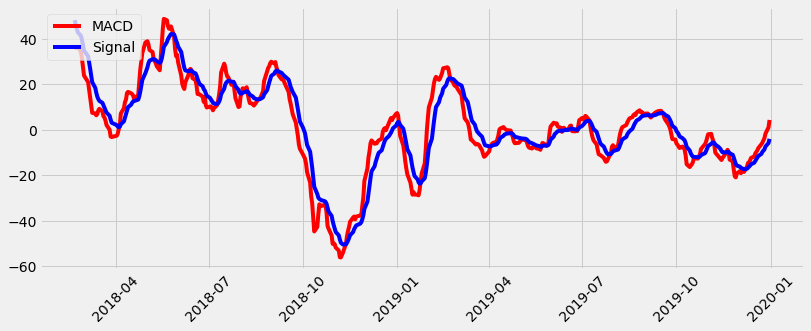

2018-04-05 00:00:00
2018-05-09 00:00:00
2018-05-15 00:00:00
2018-05-28 00:00:00
2018-06-12 00:00:00
2018-06-15 00:00:00
2018-07-10 00:00:00
2018-07-23 00:00:00
2018-08-03 00:00:00
2018-08-08 00:00:00
2018-08-20 00:00:00
2018-09-07 00:00:00
2018-11-12 00:00:00
2019-01-03 00:00:00
2019-01-24 00:00:00
2019-02-22 00:00:00
2019-04-03 00:00:00
2019-04-23 00:00:00
2019-05-22 00:00:00
2019-05-27 00:00:00
2019-05-28 00:00:00
2019-06-11 00:00:00
2019-06-12 00:00:00
2019-06-21 00:00:00
2019-06-27 00:00:00
2019-07-09 00:00:00
2019-07-29 00:00:00
2019-09-05 00:00:00
2019-09-09 00:00:00
2019-09-18 00:00:00
2019-10-23 00:00:00
2019-11-07 00:00:00
2019-11-19 00:00:00
2019-11-21 00:00:00
2019-12-09 00:00:00


In [ ]:
plt.figure(figsize=(12.2,4.5))
plt.plot(data.index,data['MACD'],label='MACD',color='red')
plt.plot(data.index,data['Signal'],label='Signal',color='blue')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.show()
df=pd.DataFrame(data,columns=['MACD','Signal'])
#rslt = df[df['MACD']==df['Signal']]

for i in range(1,len(df)):
 if df['MACD'][i] > df['Signal'][i] and df['MACD'][i-1] < df['Signal'][i-1]:
    print(df.index[i])
 elif df['MACD'][i] < df['Signal'][i] and df['MACD'][i-1] > df['Signal'][i-1]:
    print(df.index[i])

